In [1]:
import torch
from torch import nn
import torch_geometric
from torch_geometric.nn import GATConv, SAGEConv, GraphConv, GraphSAGE, GCNConv, GATv2Conv
import torch
import networkx as nx 
from torch.utils.data import Dataset
import pickle
import pdb 
import numpy as np
from torch_geometric.data import Data, NeighborSampler
import networkx as nx
from torch_geometric.loader import NeighborLoader
from torch_geometric.data import Data
import numpy as np
import pandas as pd 
import pickle
import pdb
from torch_geometric.loader import DataLoader
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj, subgraph, k_hop_subgraph
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'tools'))
from sklearn.neighbors import kneighbors_graph
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.data import Data
# from newGraphDat import GraphDataset
# from GraphDatAll import GraphDataset
from GraphDatNodeWise import GraphDataset

from sklearn.manifold import TSNE
import matplotlib as mpl
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
# import numpy as np
import scipy.io
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
torch.manual_seed(42)


In [2]:
class GATNet(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, p, h = 4):
        super(GATNet, self).__init__()
        # Define the first GAT convolution layer
        self.conv1 = GATConv(in_channels, hidden_channels*4, heads=h, dropout=p)
        # Define the second GAT convolution layer
        self.conv2 = GATConv(hidden_channels*4 * h, hidden_channels*2, heads=h, concat=True, dropout=p)
        # Define the third GAT convolution layer
        self.conv3 = GATConv(hidden_channels*2 * h, hidden_channels, heads=1, concat=True, dropout=p)
        # Define a linear layer to refine the outputs to the desired size
        self.linear = nn.Linear(hidden_channels, hidden_channels)
        self.linear2 = nn.Linear(hidden_channels, out_channels)
        self.shortcut = nn.Linear(in_channels, out_channels)
        self.p = p
        # self.sigm = nn.Sigmoid()
        # self.ta = nn.Tanh()

    def forward(self, x, edge_index):
        init = x
        # x, edge_index = data.x, data.edge_index
        # Apply dropout to the input features and pass through the first GAT layer
        x = F.elu(self.conv1(x, edge_index))
        # x = F.dropout(x, p=self.p, training=self.training)
        # Pass through the second GAT layer
        x = F.elu(self.conv2(x, edge_index))
        # x = F.dropout(x, p=self.p, training=self.training)
        # Pass through the third GAT layer
        x = self.conv3(x, edge_index)#F.dropout(x, p=self.p, training=self.training)
        x = x + self.shortcut(init)
        
        # x = F.dropout(x, p=self.p, training=self.training)
        # x = F.elu(self.conv3(x, edge_index))
        # Apply the linear layer
        x = F.dropout(self.linear(x), p=self.p, training=self.training)
        embed = x
        x = F.relu(self.linear2(x))
        
        # x[:,0] = self.sigm(x[:,0])
        # x[:,0] = self.ta(x[:,0] + 1)/2.0
        return x, embed

In [3]:
def class_loss(reconstructed_x, original_x):
    arr = [1.0, 1.0, 1.0, 1.0]
    const = np.sum(arr)
    weights = torch.log(torch.tensor([const/a for a in arr], dtype=torch.float))
    return F.cross_entropy(reconstructed_x, original_x, weight=weights)

def cosine_loss(adj, emb, ew):
    # pdb.set_trace()
    norms = torch.norm(emb, p=2, dim=1, keepdim=True)
    normalized_embeddings = emb / norms.clamp(min=1e-4)
    cosine_similarity_matrix = torch.mm(normalized_embeddings, normalized_embeddings.t())
    target_adjacency = torch.zeros_like(cosine_similarity_matrix)
    normalized_weights = ew / torch.norm(ew, p=2, keepdim=True)
    target_adjacency[adj[0], adj[1]] = normalized_weights
    # Directly using logits; no need to apply sigmoid.
    return F.binary_cross_entropy_with_logits(cosine_similarity_matrix, target_adjacency)

def total_loss_func(adj, emb, ew, reconstructed_x, original_x):
    cs = cosine_loss(adj, emb, ew)
    # cls = class_loss(reconstructed_x, original_x)
    reg_loss = nn.MSELoss()
    cls = reg_loss(reconstructed_x, original_x)
    alpha = 0.999999
    return alpha * cls + (1.0 - alpha) * cs

def round_function(x, d):
    new = []
    for r in x:
        new.append(np.round(r,decimals=d))
    # pdb.set_trace()
    return tuple(new)

In [4]:
device = "cpu"

inC = 54

nW = 8

folder_graph = './data/lots_of_node_samples/train_new_random_sample_64/graphs/'
files = os.listdir(folder_graph)
files = [file for file in files if file.endswith('.pickle') and file.startswith('1')] #and (file not in files_test)


dataset = GraphDataset(folder_graph, files, 'train', 'time')
dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=nW)

nodelabels = pd.read_csv(folder_graph+'times.csv')
# print(nodelabels['(0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0)'])

node_labels_dict = dict()
for n in nodelabels.columns:
    if n != 'Unnamed: 0':
        node_labels_dict[n] = nodelabels[n].tolist()

for n in node_labels_dict:
    print(n)
    break

reg_loss = nn.MSELoss(reduction='mean')
alpha = 0.000001#1.000#0.00001

epochs = 5

hC = 128
drops = 0.0
lrate = 0.001
decays = 5e-4
predictions_train = []
actuals_train = []
nodes_trained = []
outchannels = 1
model = GATNet(inC, hC, outchannels, drops, h=4).to(device)
optimizer = optim.AdamW(model.parameters(), lr=lrate, weight_decay=decays)
model.train()
for epoch in range(0, epochs):
    allLoss = 0
    for feat, edge, ew in dataloader:
        
        features = feat.squeeze_(0)#.to(device)
        edges = edge.squeeze_(0)#.to(device)
        edge_weights = ew.squeeze_(0)
        # Create a tensor for labels, initially filled with NaN
        labels = torch.full((features.shape[0],), float('nan'), dtype=torch.float32)
        # print(np.shape(labels))
        # Assign labels to corresponding nodes based on features
        for i, feature_vector in enumerate(features):
            feature_tuple = str(round_function(feature_vector.tolist(), 3))
            # print(feature_tuple)
            if feature_tuple in node_labels_dict:
                labels[i] = np.nanmean(node_labels_dict[feature_tuple])
                # print(labels[i])
            # break
        # break
        # print(np.shape(label))
        data = Data(x=features, edge_index=edges, y=labels, edge_attr=edge_weights)
        loader = NeighborLoader(
                    data,
                    num_neighbors=[4] * 2,
                    batch_size=32,
                    input_nodes=None
                )#.to(device)

        loss_for_one_graph = 0.0
        for subdata in loader:
            
            # print(subdata)
            # print(subdata)
            label_mask = ~torch.isnan(subdata.y) 
            if label_mask.any():
                optimizer.zero_grad()
                out, embed = model(subdata.x, subdata.edge_index)
            # known_labels = tS[label_mask]  # Labels for nodes with known convergence time
            
            #  TODO: Puneet, check if label mask works for subdata
            # subdata_labels = labels[subdata.n_id]  # subdata.n_id gives the original node indices in the batch
            # subdata_label_mask = ~torch.isnan(subdata_labels)
            # print(subdata.edge_index.shape, embed.shape, subdata.edge_attr.shape)
            
                mse_loss_val = alpha*reg_loss(out[label_mask], subdata.y[label_mask].unsqueeze_(1))
                # cos_loss_val = 0.0
                # cos_loss_val = cosine_loss(subdata.edge_index, embed, subdata.edge_attr) 
                # print('cos, mse loss : ', cos_loss_val, mse_loss_val) 
                # alpha = cos_loss_val / (mse_loss_val + cos_loss_val)
                # beta = mse_loss_val / (mse_loss_val + cos_loss_val)
                predictions_train.append(out[label_mask].detach().numpy())
                actuals_train.append(subdata.y[label_mask].detach().numpy())
                nodes_trained.append(subdata.x[label_mask].detach().numpy())
                mse_loss_val.backward()
            
                # print('cos loss only: ', cos_loss_val)        
                loss_for_one_graph += mse_loss_val.detach()
                optimizer.step()
                # total_loss = alpha * mse_loss_val #+ (1-alpha) * cos_loss_val
            # else:
                # cos_loss_val = cosine_loss(subdata.edge_index, embed, subdata.edge_attr) 
                # cos_loss_val = 0.0
                # total_loss =  (1-alpha) * cos_loss_val 
                # total_loss = 0.0
            
        # print('loss: ', loss_for_one_graph)
        allLoss += loss_for_one_graph
    print('EPOCH ', epoch, ' : ', allLoss)
    # break


(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.1, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.0, -0.0, -0.15, 0.893, 0.0, 0.15, 0.196, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0)
EPOCH  0  :  tensor(788.5679)
EPOCH  1  :  tensor(223.2195)
EPOCH  2  :  tensor(146.5076)
EPOCH  3  :  tensor(119.4616)
EPOCH  4  :  tensor(133.3004)


In [5]:
# epochs = 10
# lrate = 0.001
# optimizer = optim.AdamW(model.parameters(), lr=lrate, weight_decay=decays)
# for epoch in range(0, epochs):
#     allLoss = 0
#     for feat, edge, ew in dataloader:
        
#         features = feat.squeeze_(0)#.to(device)
#         edges = edge.squeeze_(0)#.to(device)
#         edge_weights = ew.squeeze_(0)
#         # Create a tensor for labels, initially filled with NaN
#         labels = torch.full((features.shape[0],), float('nan'), dtype=torch.float32)
#         # print(np.shape(labels))
#         # Assign labels to corresponding nodes based on features
#         for i, feature_vector in enumerate(features):
#             feature_tuple = str(round_function(feature_vector.tolist(), 3))
#             # print(feature_tuple)
#             if feature_tuple in node_labels_dict:
#                 labels[i] = np.nanmean(node_labels_dict[feature_tuple])
#                 # print(labels[i])
#             # break
#         # break
#         # print(np.shape(label))
#         data = Data(x=features, edge_index=edges, y=labels, edge_attr=edge_weights)
#         loader = NeighborLoader(
#                     data,
#                     num_neighbors=[4] * 2,
#                     batch_size=32,
#                     input_nodes=None,
#                 )

#         loss_for_one_graph = 0
#         for subdata in loader:
#             optimizer.zero_grad()
#             # print(subdata)
#             # print(subdata)
#             out, embed = model(subdata.x, subdata.edge_index)
#             # known_labels = tS[label_mask]  # Labels for nodes with known convergence time
            
#             #  TODO: Puneet, check if label mask works for subdata
#             # subdata_labels = labels[subdata.n_id]  # subdata.n_id gives the original node indices in the batch
#             # subdata_label_mask = ~torch.isnan(subdata_labels)
#             # print(subdata.edge_index.shape, embed.shape, subdata.edge_attr.shape)
#             label_mask = ~torch.isnan(subdata.y) 
#             if label_mask.any():
#                 mse_loss_val = reg_loss(out[label_mask], subdata.y[label_mask].unsqueeze_(1))
#                 cos_loss_val = cosine_loss(subdata.edge_index, embed, subdata.edge_attr) 
#                 # print('cos, mse loss : ', cos_loss_val, mse_loss_val) 
#                 # alpha = cos_loss_val / (mse_loss_val + cos_loss_val)
#                 # beta = mse_loss_val / (mse_loss_val + cos_loss_val)
#                 predictions_train.append(out[label_mask].detach().numpy())
#                 actuals_train.append(subdata.y[label_mask].detach().numpy())
#                 nodes_trained.append(subdata.x[label_mask].detach().numpy())
#                 total_loss = alpha * mse_loss_val + (1-alpha) * cos_loss_val
#             else:
#                 cos_loss_val = cosine_loss(subdata.edge_index, embed, subdata.edge_attr) 
#                 total_loss =  (1-alpha) * cos_loss_val 
#             total_loss.backward()
            
#                 # print('cos loss only: ', cos_loss_val)        
#             loss_for_one_graph += total_loss.detach()
#             optimizer.step()
#         # print('loss: ', loss_for_one_graph)
#         allLoss += loss_for_one_graph
#     print('EPOCH ', epoch, ' : ', allLoss)

In [37]:

valfolder = './data/lots_of_node_samples/test_new_random_sample_64/graphs/'
files_val= os.listdir(valfolder)
files_val = [file for file in files_val if file.endswith('.pickle') and file.startswith('1')]

dataset_val = GraphDataset(valfolder, files_val, 'test', 'time')
dataloader_val = DataLoader(dataset_val, batch_size=1, shuffle=True, num_workers=nW)
nodelabels = pd.read_csv(valfolder +'times.csv')

node_labels_dict = dict()
for n in nodelabels.columns:
    if n != 'Unnamed: 0':
        node_labels_dict[n] = nodelabels[n].tolist()

for n in node_labels_dict:
    print(n)
    break


nodelabels = pd.read_csv(valfolder +'times.csv')

node_labels_dict = dict()
for n in nodelabels.columns:
    if n != 'Unnamed: 0':
        node_labels_dict[n] = nodelabels[n].tolist()

for n in node_labels_dict:
    print(n)
    break

predictions = []
actual_labels = []
nodes_labeled = []
output_label = dict()
model.eval()

with torch.no_grad():
    for feat, edge, ew in dataloader_val:
        features = feat.squeeze_(0)#.to(device)
        edges = edge.squeeze_(0)#.to(device)
        edge_weights = ew.squeeze_(0)
        # Create a tensor for labels, initially filled with NaN
        labels = torch.full((features.shape[0],), float('nan'), dtype=torch.float32)
        # print(np.shape(labels))
        # Assign labels to corresponding nodes based on features
        for i, feature_vector in enumerate(features):
            feature_tuple = str(round_function(feature_vector.tolist(), 3))
            # print(feature_tuple)
            if feature_tuple in node_labels_dict:
                labels[i] = np.nanmean(node_labels_dict[feature_tuple])
                # print(labels[i])
            # break

        data = Data(x=features, edge_index=edges, y=labels, edge_attr=edge_weights)
        loader = NeighborLoader(
                    data,
                    num_neighbors=[4] * 2,
                    batch_size=32,
                    input_nodes=None,
                )

        loss_for_one_graph = 0
        for subdata in loader:
            # print(subdata)
            # print(subdata)
            out, embed = model(subdata.x, subdata.edge_index)

            label_mask = ~torch.isnan(subdata.y) 
            if label_mask.any():
                nodes_labeled.append(subdata.x[label_mask].cpu().numpy())
                predictions.append(out[label_mask].cpu().numpy())
                actual_labels.append(subdata.y[label_mask].cpu().numpy())

(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0, 0.1, 0.0, 0.2, 0.0, 0.1, 0.0, 0.3, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.15, 0.0, 0.913, -0.0, -0.15, 0.893, -0.15, 0.0, 0.388, 1.0, 1.0, 0.0)
(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0, 0.1, 0.0, 0.2, 0.0, 0.1, 0.0, 0.3, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.15, 0.0, 0.913, -0.0, -0.15, 0.893, -0.15, 0.0, 0.388, 1.0, 1.0, 0.0)


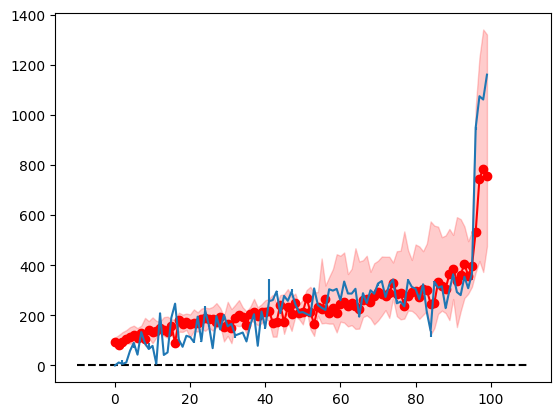

In [ ]:
# print(np.shape(predictions[0]))
# print(np.shape(actual_labels[0]), actual_labels)
# print(predictions[0], actual_labels[0])

inp = []
outp = []
nodes_ = []



for p, a, n in zip(predictions, actual_labels, nodes_labeled):
    for pp, aa, nn in zip(p, a, n):
        inp.append(aa)
        outp.append(pp[0])
        nodes_.append(tuple(nn))
        

df = pd.DataFrame({'nodes': nodes_, 'inputs': inp, 'outputs': outp})
grouped_data = df.groupby(by=['nodes'], as_index=False).agg(list)#.reset_index()
# print(grouped_data.nodes)

# print(df.inputs.tolist())
plt.figure(0)
# for row in 
error_fill1 = []
error_fill2 = []
meanpoints = []
ids = []
meanpreds = []
medianpoints = []
errpred25 = []
errpred75 = []
medianpreds = []
for id, (i, o, n) in enumerate(zip(grouped_data.inputs, grouped_data.outputs, grouped_data.nodes)):
    # print(i)
    # print(o)
    # break
    #  why is it missing from dict??
    # print(tuple(n), node_labels_dict[str(tuple(n))])
    # break
    i = list(node_labels_dict[str(tuple(n))])
    medianpoints.append(np.nanmedian(i))
    perc25 = np.nanpercentile(i, 25)
    # print(perc25)
    perc75 = np.nanpercentile(i, 75)
    error_fill1.append(perc25)
    error_fill2.append(perc75)
    meanpoints.append(np.nanmean(i))
    ids.append(id)
    meanpreds.append(np.nanmean(o))
    errpred25.append(np.nanpercentile(o, 25))
    errpred75.append(np.nanpercentile(o, 75))
    medianpreds.append(np.nanmedian(o))



meanpoints = np.array(meanpoints)
arr = np.argsort(meanpoints)
meanpoints = meanpoints[arr]
# print(meanpoints)
# arr = ids
error_fill2 = np.array(error_fill2)[arr]
error_fill1 = np.array(error_fill1)[arr]
medianpoints = np.array(medianpoints)[arr]
meanpreds = np.array(meanpreds)[arr]
ids = np.array(ids)
errpred25 = np.array(errpred25)[arr]
errpred75 = np.array(errpred75)[arr]
medianpreds = np.array(medianpreds)[arr]
# print(errpred25[0] - medianpreds[0])
# print(medianpreds-errpred25)
plt.errorbar(ids, medianpreds, yerr=[medianpreds-errpred25, errpred75-medianpreds], fmt='')
# print(arr)
plt.plot(ids, medianpoints, 'ro-')
# print(medianpoints[0] - error_fill1[0], medianpoints[0] + error_fill2[0])
plt.fill_between(ids, error_fill1, error_fill2, color='red', alpha=0.2)
plt.plot(ids, meanpreds, 'b+')
plt.hlines(0.0, -5, len(ids) + 5, 'k', 'dashed')

plt.show()


In [8]:
# print(predictions_train[0])
# print(actuals_train[0])

In [9]:

# inp = []
# outp = []

# for p, a in zip(predictions_train, actuals_train):
#     for pp, aa in zip(p[0], a):
#         inp.append(aa)
#         outp.append(pp)

# plt.figure(0)
# for id, (i, o) in enumerate(zip(inp, outp)):
#     plt.plot(id, i, 'ro')
#     plt.plot(id, o, 'b+')

# plt.show()

In [26]:

folder_graph = './data/lots_of_node_samples/train_new_random_sample_64/graphs/'
files = os.listdir(folder_graph)
files = [file for file in files if file.endswith('.pickle') and file.startswith('1')] #and (file not in files_test)

nodelabels = pd.read_csv(folder_graph+'times.csv')
# print(nodelabels['(0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0)'])

node_labels_dict = dict()
for n in nodelabels.columns:
    if n != 'Unnamed: 0':
        node_labels_dict[n] = nodelabels[n].tolist()

# for n in node_labels_dict:
    # print(n)
    # break


inp = []
outp = []
nodes_ = []



for p, a, n in zip(predictions_train, actuals_train, nodes_trained):
    for pp, aa, nn in zip(p, a, n):
        inp.append(aa)
        outp.append(pp[0])
        nodes_.append(tuple(nn))
        

df = pd.DataFrame({'nodes': nodes_, 'inputs': inp, 'outputs': outp})
grouped_data = df.groupby(by=['nodes'], as_index=False).agg(list)#.reset_index()
# print(grouped_data.nodes)

# print(df.inputs.tolist())
plt.figure(0)
# for row in 
error_fill1 = []
error_fill2 = []
meanpoints = []
ids = []
meanpreds = []
medianpoints = []
errpred25 = []
errpred75 = []
medianpreds = []
for id, (i, o, n) in enumerate(zip(grouped_data.inputs, grouped_data.outputs, grouped_data.nodes)):
    # print(i)
    # print(o)
    # print(n)
    # break
    #  why is it missing from dict??
    # print(tuple(n), node_labels_dict[str(tuple(n))])
    # break
    i = list(node_labels_dict[str(tuple(n))])
    medianpoints.append(np.nanmedian(i))
    perc25 = np.nanpercentile(i, 25)
    # print(perc25)
    perc75 = np.nanpercentile(i, 75)
    error_fill1.append(perc25)
    error_fill2.append(perc75)
    meanpoints.append(np.nanmean(i))
    ids.append(id)
    meanpreds.append(np.nanmean(o))
    errpred25.append(np.nanpercentile(o, 25))
    errpred75.append(np.nanpercentile(o, 75))
    medianpreds.append(np.nanmedian(o))


plt.show()

<Figure size 640x480 with 0 Axes>

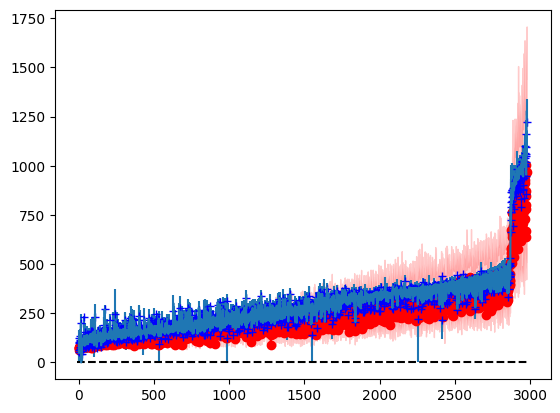

In [36]:


meanpoints = np.array(meanpoints)
arr = np.argsort(meanpoints)
meanpoints = meanpoints[arr]
# print(meanpoints)

error_fill2 = np.array(error_fill2)[arr]
error_fill1 = np.array(error_fill1)[arr]
medianpoints = np.array(medianpoints)[arr]
meanpreds = np.array(meanpreds)[arr]
ids = np.array(ids)
errpred25 = np.array(errpred25)[arr]
errpred75 = np.array(errpred75)[arr]
medianpreds = np.array(medianpreds)[arr]
# print(errpred25[0] - medianpreds[0])
# print(medianpreds-errpred25)
yErr=[medianpreds-errpred25, errpred75-medianpreds]
plt.errorbar(ids, medianpreds, yerr=yErr, fmt='')
# plt.errorbar(ids, np.clip(meanpreds, a_min=0.001, a_max = 10000), yerr=[np.clip(medianpreds-errpred25, a_min=0.001, a_max=10000), np.clip(errpred75-medianpreds, a_min=0.001, a_max=10000)], fmt='')
# print(arr)
plt.plot(ids, medianpoints, 'ro-')
# print(medianpoints[0] - error_fill1[0], medianpoints[0] + error_fill2[0])
plt.fill_between(ids, error_fill1, error_fill2, color='red', alpha=0.2)
plt.hlines(0.0, -10, len(ids) + 10, 'k', 'dashed')
plt.plot(ids, meanpreds, 'b+')
# for m, e1, e2 in zip(medianpreds, errpred25, errpred75):
#     if m-e1 <= 0 :
#         print(m, e1, e2)
#         break


In [28]:
for id, (m, e1, e2) in enumerate(zip(medianpreds, errpred25, errpred75)):
    if m-e1 < 0 or e2-m < 0:
        print(m, e1, e2, m-e1, e2-m)
        grouped_data.iloc[id]['nodes']

In [35]:
np.shape(yErr)
for e1, e2 in np.array(yErr).T:
    if e1 < 0 or e2 < 0:
        print(e1, e2)